In [6]:
import pickle

with open("dataset/resplan_numeric_100.pkl", "rb") as f:
    data = pickle.load(f)

nodes = data["nodes"]
edge_index = data["edge_index"]
edge_attr = data["edge_attr"]
text = data["text"]

print(len(nodes))
print(nodes[0].shape)
print(edge_attr[0].shape)

100
(8, 11)
(10, 10)


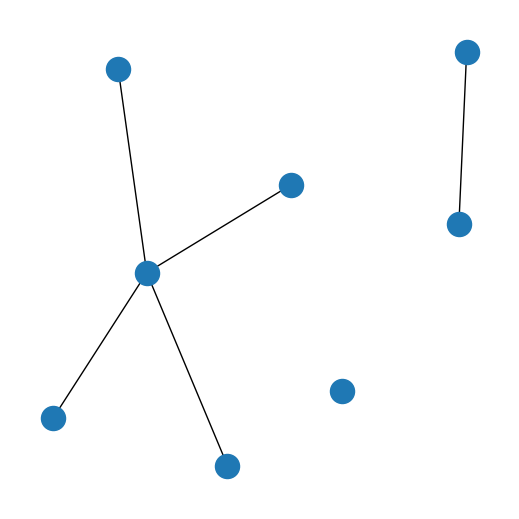

In [23]:
import networkx as nx
import matplotlib.pyplot as plt
i=0
x=nodes[i]
edge_index_1=edge_index[i]
G=nx.Graph()


# node positions from centroid features
cx = x[:,7]
cy = x[:,8]

for n in range(len(x)):
    G.add_node(n, pos=(cx[n], cy[n]))

for s,d in edge_index_1.T:
    G.add_edge(int(s), int(d))

pos = nx.get_node_attributes(G,"pos")

plt.figure(figsize=(5,5))
nx.draw(G,pos,node_size=300)
plt.gca()
plt.show()

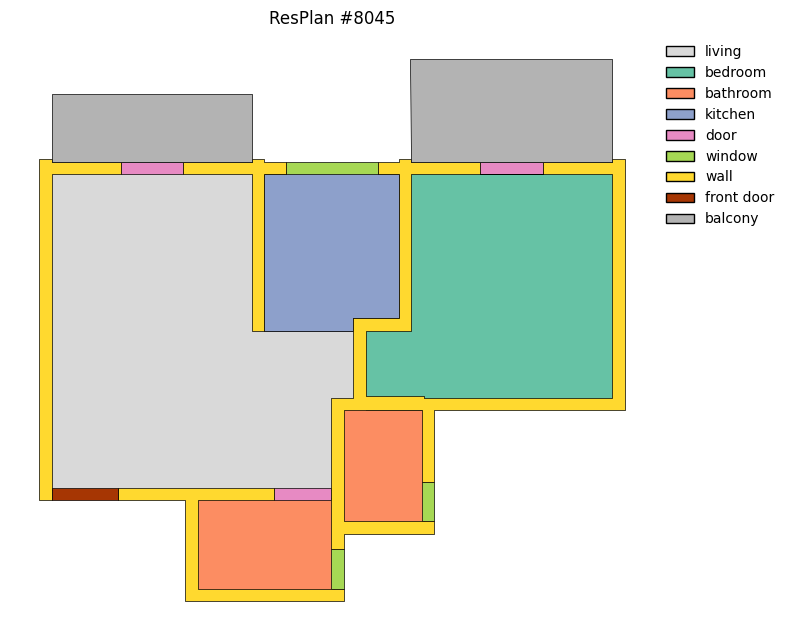

In [24]:
from dataset.resplan_utils import plot_plan

# load numeric subset
with open("dataset/resplan_numeric_100.pkl","rb") as f:
    data = pickle.load(f)

nodes = data["nodes"]
edges = data["edge_index"]
plan_idx = data["plan_idx"]


orig_idx = plan_idx[i]

# load ResPlan
with open("dataset/ResPlan.pkl","rb") as f:
    plans = pickle.load(f)

plan = plans[orig_idx]

# show floorplan
plot_plan(plan, title=f"ResPlan #{orig_idx}")
plt.show()

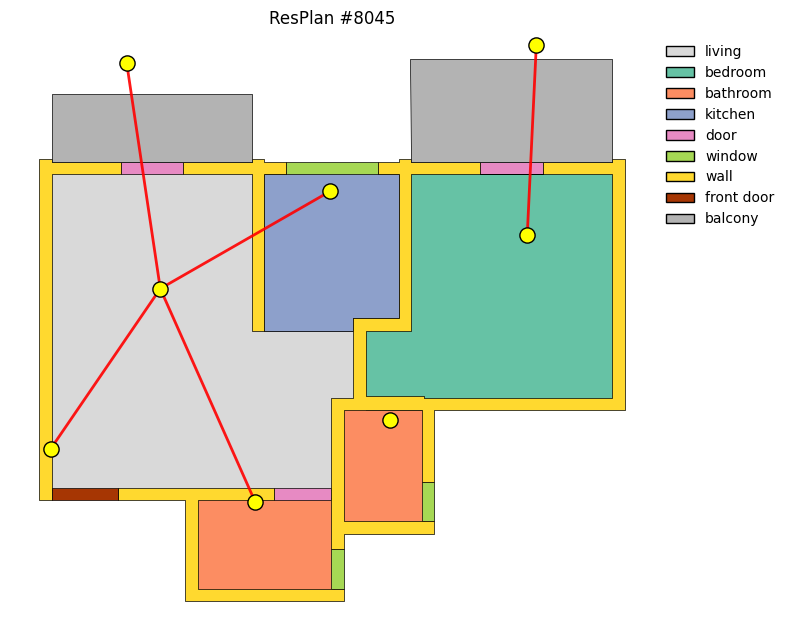

In [25]:
# Draw floorplan first
plot_plan(plan, title=f"ResPlan #{orig_idx}")
ax = plt.gca()

# Floorplan bounds
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
xmin, xmax = min(x0, x1), max(x0, x1)
ymin, ymax = min(y0, y1), max(y0, y1)

# Map normalized node coords (0..1) into floorplan axis coords
pos_plan = {
    k: (
        xmin + float(v[0]) * (xmax - xmin),
        ymin + float(v[1]) * (ymax - ymin),
    )
    for k, v in pos.items()
}

# Overlay graph
edge_coll = nx.draw_networkx_edges(
    G, pos_plan, ax=ax, edge_color="red", width=2.0, alpha=0.9
)
node_coll = nx.draw_networkx_nodes(
    G, pos_plan, ax=ax, node_color="yellow", edgecolors="black", node_size=120, alpha=1.0
)

# Keep graph above floorplan
if edge_coll is not None:
    edge_coll.set_zorder(10)
if node_coll is not None:
    node_coll.set_zorder(11)

# Preserve view/aspect/orientation
ax.set_xlim(x0, x1)
ax.set_ylim(y0, y1)
ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

Building dataset

In [11]:
import torch
from torch_geometric.data import Data

def build_dataset(nodes, edge_index, edge_attr):
    dataset = []

    for i in range(len(nodes)):
        x = torch.tensor(nodes[i], dtype=torch.float32)
        ei = torch.tensor(edge_index[i], dtype=torch.long)
        ea = torch.tensor(edge_attr[i], dtype=torch.float32)

        # target = cx,cy,w,h
        y = x[:, 7:11]   # adjust if ordering differs

        data = Data(
            x=x,
            edge_index=ei,
            edge_attr=ea,
            y=y
        )
        dataset.append(data)

    return dataset

/home/dexter/projects/FloorPlan-Pipeline/venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train Test split

In [12]:
dataset = build_dataset(nodes, edge_index, edge_attr)

train_dataset = dataset[:80]
test_dataset  = dataset[80:]

In [13]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1)

In [14]:
import torch
import torch.nn as nn
from torch_geometric.nn import GINEConv


class RoughLayoutGNN(nn.Module):
    def __init__(self, node_dim=11, edge_dim=10, hidden=128):
        super().__init__()

        def mlp(in_dim, out_dim):
            return nn.Sequential(
                nn.Linear(in_dim, hidden),
                nn.ReLU(),
                nn.Linear(hidden, out_dim)
            )

        self.conv1 = GINEConv(mlp(node_dim, hidden), edge_dim=edge_dim)
        self.conv2 = GINEConv(mlp(hidden, hidden), edge_dim=edge_dim)
        self.conv3 = GINEConv(mlp(hidden, hidden), edge_dim=edge_dim)

        self.head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 4)   # cx,cy,w,h
        )

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr

        x = self.conv1(x, edge_index, edge_attr)
        x = torch.relu(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = torch.relu(x)

        x = self.conv3(x, edge_index, edge_attr)
        x = torch.relu(x)

        out = self.head(x)
        return out

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RoughLayoutGNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [16]:
print(device)

cuda


In [17]:
def layout_loss(pred, target):
    # pred,target: [total_nodes,4]
    return torch.nn.functional.l1_loss(pred, target)

Training loop

In [18]:
def train_epoch():
    model.train()
    total_loss = 0

    for data in train_loader:
        data = data.to(device)

        optimizer.zero_grad()
        pred = model(data)

        loss = layout_loss(pred, data.y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

In [19]:
@torch.no_grad()
def eval_epoch():
    model.eval()
    total_loss = 0

    for data in test_loader:
        data = data.to(device)
        pred = model(data)
        loss = layout_loss(pred, data.y)
        total_loss += loss.item()

    return total_loss / len(test_loader)

In [20]:
for epoch in range(50):
    train_loss = train_epoch()
    test_loss  = eval_epoch()

    print(f"Epoch {epoch:03d} | train {train_loss:.4f} | test {test_loss:.4f}")

Epoch 000 | train 0.2682 | test 0.2263
Epoch 001 | train 0.1985 | test 0.1935
Epoch 002 | train 0.1740 | test 0.1800
Epoch 003 | train 0.1582 | test 0.1577
Epoch 004 | train 0.1424 | test 0.1488
Epoch 005 | train 0.1347 | test 0.1392
Epoch 006 | train 0.1256 | test 0.1310
Epoch 007 | train 0.1169 | test 0.1307
Epoch 008 | train 0.1114 | test 0.1264
Epoch 009 | train 0.1063 | test 0.1295
Epoch 010 | train 0.1030 | test 0.1043
Epoch 011 | train 0.0926 | test 0.0992
Epoch 012 | train 0.0878 | test 0.1018
Epoch 013 | train 0.0857 | test 0.0935
Epoch 014 | train 0.0862 | test 0.0923
Epoch 015 | train 0.0779 | test 0.0853
Epoch 016 | train 0.0735 | test 0.0853
Epoch 017 | train 0.0717 | test 0.0785
Epoch 018 | train 0.0684 | test 0.0782
Epoch 019 | train 0.0666 | test 0.0764
Epoch 020 | train 0.0634 | test 0.0818
Epoch 021 | train 0.0644 | test 0.0801
Epoch 022 | train 0.0618 | test 0.0695
Epoch 023 | train 0.0547 | test 0.0706
Epoch 024 | train 0.0551 | test 0.0673
Epoch 025 | train 0.0511 

In [21]:
import matplotlib.pyplot as plt

@torch.no_grad()
def visualize_prediction(sample_idx=0):
    data = test_dataset[sample_idx].to(device)
    pred = model(data).cpu().numpy()
    gt   = data.y.cpu().numpy()

    fig, ax = plt.subplots(figsize=(5,5))

    for box, color in [(gt,"green"), (pred,"red")]:
        for cx,cy,w,h in box:
            x0 = cx - w/2
            y0 = cy - h/2
            rect = plt.Rectangle(
                (x0,y0), w, h,
                fill=False,
                edgecolor=color,
                linewidth=2
            )
            ax.add_patch(rect)

    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    ax.set_aspect("equal")
    plt.show()

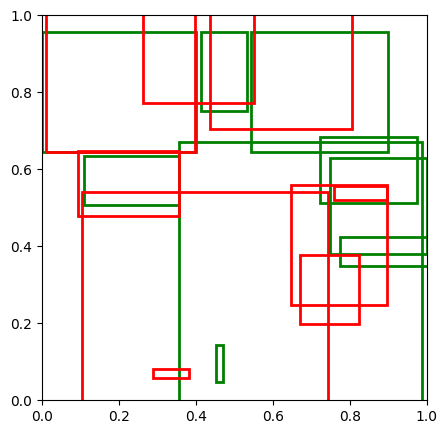

In [22]:
visualize_prediction(0)